In [2]:
import networkx as nx
import os
import pickle

from css import *
from graphs.foliation import foliation
from graphs.graph_codes import *

In [3]:
code_dict = {
    "steane": SteaneCode(),
    "shor": ShorCode(),
}

surface_dict = {f"surface_[[{d**2},1,{d}]]": SurfaceCode(d) for d in range(3, 12)}
name_bb_list = [
    "[[72,12,6]]",
    "[[90,8,10]]",
    "[[108,8,10]]",
    "[[144, 12, 12]]"
    ]
bb_codes_dict = {f"bb_code_{name}": BivariateBicycleCode.name(name) for name in name_bb_list}

hgp_list = [
        "34_4", "52_4", "80_16", "106_16", "130_4",
    ]

hgp_codes_dict = {f"hgp_code_{name}": HyperGraphProductCode.from_file(name) for name in hgp_list}

total_code_dict = code_dict | bb_codes_dict | hgp_codes_dict

In [4]:
%cd 

/home/paul


In [5]:
def save_graph(graph, name):
    path = "/home/paul/programming/qec_hqi/src/data/graphs/"
    file_name = path + f"{name}.pkl"
    with open(file_name, 'wb') as f:
        pickle.dump(graph, f)

In [6]:
layer_list = [1, 3, 5]
for name, code in total_code_dict.items():
    for k in layer_list:
        name = f"foliation_{k}_{name}"
        save_graph(foliation(code, k), name)
    name = f"bell_{name}"
    save_graph(GraphCode.from_stabilizer_code(code).graph_state_bell_init(), name)
    name = f"init_0_{name}"
    save_graph(GraphCode.from_stabilizer_code(code).graph_state_0_init(), name)

In [ ]:
file_name = "/home/paul/programming/qec_hqi/src/data/graphs/bell_foliation_5_foliation_3_foliation_1_bb_code_[[72,12,6]].pkl"
with open(file_name, 'rb') as f:
    G = pickle.load(f)

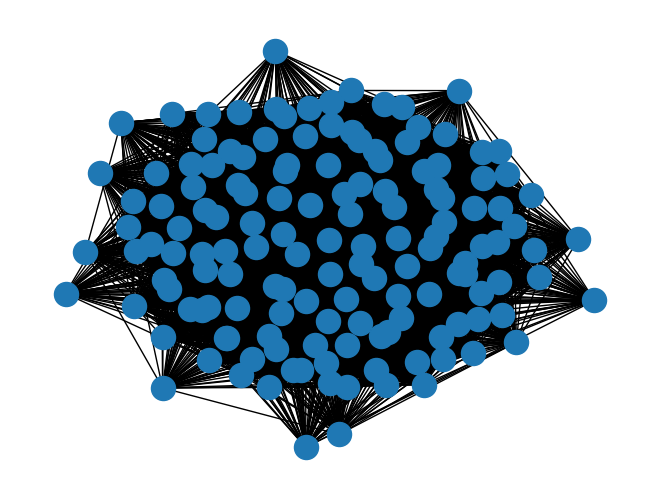

In [ ]:
nx.draw(G)